In [1]:
# XAI Study Analysis
# Research Questions:
# RQ1: Do explanations increase trust?
# RQ2: Do explanations increase selection rate?
# RQ3: Do explanation types differ in effectiveness?

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_rel, chi2_contingency
import warnings

warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("XAI Study Analysis")
print("=" * 60)
print("Loading data...\n")

# Load the synthetic data
df = pd.read_csv("../data/xai_study_results.csv")

print(f"Data loaded successfully")
print(f"Total rows: {len(df):,}")
print(f"Total participants: {df['participant_id'].nunique()}")
print(f"Interactions per participant: {len(df) // df['participant_id'].nunique()}")
print("\n" + "=" * 60)

XAI Study Analysis
Loading data...

Data loaded successfully
Total rows: 240
Total participants: 20
Interactions per participant: 12



In [2]:
# Section 2: Data Overview and Descriptive Statistics
print("\nSECTION 2: DATA OVERVIEW")
print("=" * 60)

# Basic data structure
print("\nDataset Structure:")
print(f"  Columns: {len(df.columns)}")
print(f"  Participants: {df['participant_id'].nunique()}")
print(f"  Total observations: {len(df)}")

# Check data completeness
print("\nMissing Values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("  No missing values - data is complete")
else:
    print(missing[missing > 0])

# Participant demographics
print("\nParticipant Breakdown:")
print(f"  Total participants: {df['participant_id'].nunique()}")

# Condition order balance
order_balance = df.groupby('participant_id')['condition_order'].first().value_counts()
print("\nCondition Order Balance:")
for order, count in order_balance.items():
    print(f"  {order}: {count} participants ({count/df['participant_id'].nunique()*100:.1f}%)")

# Explanation type distribution
exp_dist = df[df['explanation_shown'] == True]['explanation_type'].value_counts()
print("\nExplanation Type Distribution (when shown):")
for exp_type, count in exp_dist.items():
    print(f"  {exp_type.capitalize()}: {count} instances")

# Genre preferences
print("\nTop 5 Favorite Genres:")
genre_counts = df.groupby('participant_id')['favorite_genre'].first().value_counts().head(5)
for genre, count in genre_counts.items():
    print(f"  {genre}: {count} participants")

print("\n" + "=" * 60)


SECTION 2: DATA OVERVIEW

Dataset Structure:
  Columns: 24
  Participants: 20
  Total observations: 240

Missing Values:
explanation_text    120
dtype: int64

Participant Breakdown:
  Total participants: 20

Condition Order Balance:
  No_Explanation_First: 20 participants (100.0%)

Explanation Type Distribution (when shown):
  Similarity: 40 instances
  Rating: 40 instances
  Popularity: 40 instances

Top 5 Favorite Genres:
  Horror: 4 participants
  Children: 3 participants
  Thriller: 3 participants
  Comedy: 2 participants
  Sci-Fi: 2 participants



In [3]:
# Section 3: RQ1 Analysis - Trust Comparison
print("\nSECTION 3: RQ1 - DO EXPLANATIONS INCREASE TRUST?")
print("=" * 60)

# Separate data by explanation condition
no_exp_data = df[df['explanation_shown'] == False].copy()
with_exp_data = df[df['explanation_shown'] == True].copy()

print("\nData Split:")
print(f"  Without Explanation: {len(no_exp_data)} observations")
print(f"  With Explanation: {len(with_exp_data)} observations")

# Calculate mean trust scores
trust_no_exp = no_exp_data['trust_mean'].mean()
trust_with_exp = with_exp_data['trust_mean'].mean()
trust_diff = trust_with_exp - trust_no_exp

print("\nDescriptive Statistics - Trust Scores:")
print(f"  Without Explanation:")
print(f"    Mean: {trust_no_exp:.3f}")
print(f"    SD: {no_exp_data['trust_mean'].std():.3f}")
print(f"    Min: {no_exp_data['trust_mean'].min():.3f}")
print(f"    Max: {no_exp_data['trust_mean'].max():.3f}")

print(f"\n  With Explanation:")
print(f"    Mean: {trust_with_exp:.3f}")
print(f"    SD: {with_exp_data['trust_mean'].std():.3f}")
print(f"    Min: {with_exp_data['trust_mean'].min():.3f}")
print(f"    Max: {with_exp_data['trust_mean'].max():.3f}")

print(f"\n  Difference: +{trust_diff:.3f}")
print(f"  Percentage increase: {(trust_diff/trust_no_exp)*100:.1f}%")

# Prepare paired data for statistical test
# Group by participant and condition to get paired observations
paired_data = df.groupby(['participant_id', 'explanation_shown'])['trust_mean'].mean().unstack()

trust_without = paired_data[False].values
trust_with = paired_data[True].values

# Paired t-test
t_stat, p_value = ttest_rel(trust_with, trust_without)

# Calculate Cohen's d for paired samples
diff = trust_with - trust_without
cohens_d = diff.mean() / diff.std()

print("\nStatistical Test - Paired t-test:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.6f}")
print(f"  Cohen's d: {cohens_d:.4f}")

# Interpret results
if p_value < 0.001:
    sig_level = "p < 0.001 (highly significant)"
elif p_value < 0.01:
    sig_level = "p < 0.01 (very significant)"
elif p_value < 0.05:
    sig_level = "p < 0.05 (significant)"
else:
    sig_level = f"p = {p_value:.3f} (not significant)"

# Interpret effect size
if abs(cohens_d) < 0.2:
    effect_size = "negligible"
elif abs(cohens_d) < 0.5:
    effect_size = "small"
elif abs(cohens_d) < 0.8:
    effect_size = "medium"
else:
    effect_size = "large"

print(f"\nInterpretation:")
print(f"  Significance: {sig_level}")
print(f"  Effect size: {effect_size}")

print("\nConclusion:")
if p_value < 0.05:
    print(f"  ✓ RQ1 SUPPORTED: Explanations significantly increase trust")
    print(f"    (Mean difference = {trust_diff:.3f}, {sig_level}, d = {cohens_d:.3f})")
else:
    print(f"  ✗ RQ1 NOT SUPPORTED: No significant difference in trust")

print("\n" + "=" * 60)


SECTION 3: RQ1 - DO EXPLANATIONS INCREASE TRUST?

Data Split:
  Without Explanation: 120 observations
  With Explanation: 120 observations

Descriptive Statistics - Trust Scores:
  Without Explanation:
    Mean: 2.318
    SD: 0.854
    Min: 1.000
    Max: 4.000

  With Explanation:
    Mean: 4.272
    SD: 0.598
    Min: 2.200
    Max: 5.000

  Difference: +1.953
  Percentage increase: 84.3%

Statistical Test - Paired t-test:
  t-statistic: 19.3899
  p-value: 0.000000
  Cohen's d: 4.4483

Interpretation:
  Significance: p < 0.001 (highly significant)
  Effect size: large

Conclusion:
  ✓ RQ1 SUPPORTED: Explanations significantly increase trust
    (Mean difference = 1.953, p < 0.001 (highly significant), d = 4.448)




SECTION 4: RQ1 VISUALIZATION

✓ Chart saved as: rq1_trust_comparison.png


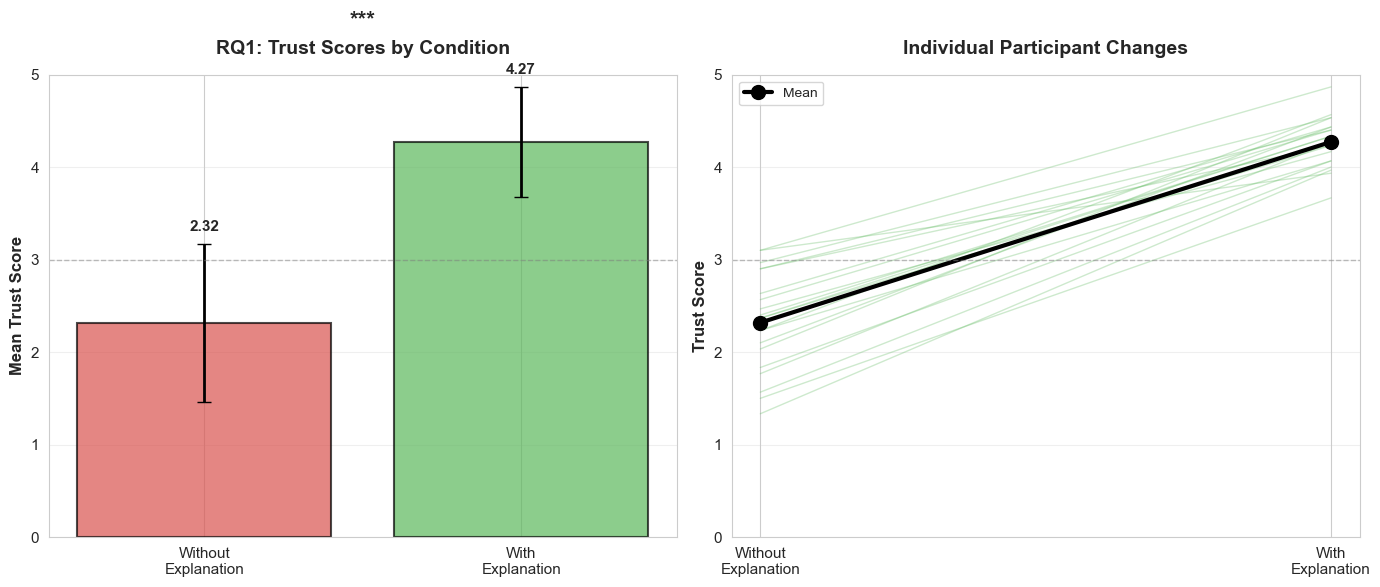

In [4]:
# Section 4: RQ1 Visualization
print("\nSECTION 4: RQ1 VISUALIZATION")
print("=" * 60)

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Bar chart comparing mean trust
ax1 = axes[0]
conditions = ['Without\nExplanation', 'With\nExplanation']
means = [trust_no_exp, trust_with_exp]
sds = [no_exp_data['trust_mean'].std(), with_exp_data['trust_mean'].std()]

bars = ax1.bar(conditions, means, color=['#d9534f', '#5cb85c'], alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.errorbar(conditions, means, yerr=sds, fmt='none', color='black', capsize=5, linewidth=2)

ax1.set_ylabel('Mean Trust Score', fontsize=12, fontweight='bold')
ax1.set_title('RQ1: Trust Scores by Condition', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylim(0, 5)
ax1.axhline(y=3, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, mean, sd) in enumerate(zip(bars, means, sds)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + sd + 0.1,
             f'{mean:.2f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add significance annotation
if p_value < 0.05:
    y_max = max(means) + max(sds) + 0.3
    ax1.plot([0, 1], [y_max, y_max], 'k-', linewidth=1.5)
    sig_text = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*'
    ax1.text(0.5, y_max + 0.1, sig_text, ha='center', fontsize=16, fontweight='bold')

# Plot 2: Paired data showing individual changes
ax2 = axes[1]

# Plot each participant's change
for i in range(len(trust_without)):
    color = '#5cb85c' if trust_with[i] > trust_without[i] else '#d9534f'
    alpha = 0.3
    ax2.plot([0, 1], [trust_without[i], trust_with[i]], 
             color=color, alpha=alpha, linewidth=1)

# Plot means
ax2.plot([0, 1], [trust_without.mean(), trust_with.mean()], 
         color='black', linewidth=3, marker='o', markersize=10, label='Mean')

ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Without\nExplanation', 'With\nExplanation'], fontsize=11)
ax2.set_ylabel('Trust Score', fontsize=12, fontweight='bold')
ax2.set_title('Individual Participant Changes', fontsize=14, fontweight='bold', pad=15)
ax2.set_ylim(0, 5)
ax2.axhline(y=3, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax2.grid(axis='y', alpha=0.3)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('rq1_trust_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Chart saved as: rq1_trust_comparison.png")
plt.show()

print("\n" + "=" * 60)

In [5]:
# Section 5: RQ2 Analysis - Selection Behavior
print("\nSECTION 5: RQ2 - DO EXPLANATIONS INCREASE SELECTION RATE?")
print("=" * 60)

# Calculate selection rates
selection_no_exp = no_exp_data['decision'].mean()
selection_with_exp = with_exp_data['decision'].mean()
selection_diff = selection_with_exp - selection_no_exp

print("\nDescriptive Statistics - Selection Rates:")
print(f"  Without Explanation:")
print(f"    Selection rate: {selection_no_exp:.1%}")
print(f"    Selected: {no_exp_data['decision'].sum()} / {len(no_exp_data)}")

print(f"\n  With Explanation:")
print(f"    Selection rate: {selection_with_exp:.1%}")
print(f"    Selected: {with_exp_data['decision'].sum()} / {len(with_exp_data)}")

print(f"\n  Difference: +{selection_diff:.1%}")
print(f"  Percentage point increase: {selection_diff*100:.1f} pp")

# CORRECTED: Match decisions movie-by-movie
# Each participant sees the same 6 movies in both conditions
# We need to pair by participant AND movie position

# Create unique movie identifier per participant
df_sorted = df.sort_values(['participant_id', 'condition', 'movieId'])

# Get decisions for each condition
no_exp_decisions = df_sorted[df_sorted['explanation_shown'] == False]['decision'].values
with_exp_decisions = df_sorted[df_sorted['explanation_shown'] == True]['decision'].values

# Count the 2x2 table (movie-level pairs)
both_yes = ((no_exp_decisions == 1) & (with_exp_decisions == 1)).sum()
both_no = ((no_exp_decisions == 0) & (with_exp_decisions == 0)).sum()
no_then_yes = ((no_exp_decisions == 0) & (with_exp_decisions == 1)).sum()
yes_then_no = ((no_exp_decisions == 1) & (with_exp_decisions == 0)).sum()

print("\nPaired Decision Patterns (Movie-Level):")
print(f"  Selected in BOTH conditions: {both_yes} movies")
print(f"  Selected in NEITHER condition: {both_no} movies")
print(f"  Only selected WITH explanation: {no_then_yes} movies")
print(f"  Only selected WITHOUT explanation: {yes_then_no} movies")

# McNemar's test
b = yes_then_no  # Selected without but not with
c = no_then_yes  # Selected with but not without

print(f"\nDiscordant Pairs (the ones that matter):")
print(f"  Changed from NO to YES: {c} movies")
print(f"  Changed from YES to NO: {b} movies")

if (b + c) > 0:
    mcnemar_stat = ((abs(b - c) - 1) ** 2) / (b + c)
    mcnemar_p = 1 - stats.chi2.cdf(mcnemar_stat, 1)
else:
    mcnemar_stat = 0
    mcnemar_p = 1.0

print("\nStatistical Test - McNemar's Test:")
print(f"  Chi-square statistic: {mcnemar_stat:.4f}")
print(f"  p-value: {mcnemar_p:.6f}")

# Interpret results
if mcnemar_p < 0.001:
    sig_level = "p < 0.001 (highly significant)"
elif mcnemar_p < 0.01:
    sig_level = "p < 0.01 (very significant)"
elif mcnemar_p < 0.05:
    sig_level = "p < 0.05 (significant)"
else:
    sig_level = f"p = {mcnemar_p:.3f} (not significant)"

print(f"\nInterpretation:")
print(f"  Significance: {sig_level}")

# Calculate odds ratio
if b > 0 and c > 0:
    odds_ratio = c / b
    print(f"  Odds ratio: {odds_ratio:.2f}")
    print(f"    (Movies were {odds_ratio:.1f}x more likely to be selected with explanations)")
elif c > 0:
    print(f"  Odds ratio: Infinity (all changes favored WITH explanations)")
elif b > 0:
    print(f"  Odds ratio: 0 (all changes favored WITHOUT explanations)")

print("\nConclusion:")
if mcnemar_p < 0.05:
    print(f"  ✓ RQ2 SUPPORTED: Explanations significantly increase selection rate")
    print(f"    ({c} movies changed NO→YES vs {b} changed YES→NO, {sig_level})")
else:
    print(f"  ✗ RQ2 NOT SUPPORTED: No significant difference in selection rate")

print("\n" + "=" * 60)


SECTION 5: RQ2 - DO EXPLANATIONS INCREASE SELECTION RATE?

Descriptive Statistics - Selection Rates:
  Without Explanation:
    Selection rate: 35.8%
    Selected: 43 / 120

  With Explanation:
    Selection rate: 90.8%
    Selected: 109 / 120

  Difference: +55.0%
  Percentage point increase: 55.0 pp

Paired Decision Patterns (Movie-Level):
  Selected in BOTH conditions: 41 movies
  Selected in NEITHER condition: 9 movies
  Only selected WITH explanation: 68 movies
  Only selected WITHOUT explanation: 2 movies

Discordant Pairs (the ones that matter):
  Changed from NO to YES: 68 movies
  Changed from YES to NO: 2 movies

Statistical Test - McNemar's Test:
  Chi-square statistic: 60.3571
  p-value: 0.000000

Interpretation:
  Significance: p < 0.001 (highly significant)
  Odds ratio: 34.00
    (Movies were 34.0x more likely to be selected with explanations)

Conclusion:
  ✓ RQ2 SUPPORTED: Explanations significantly increase selection rate
    (68 movies changed NO→YES vs 2 changed YE


SECTION 6: RQ2 VISUALIZATION

✓ Chart saved as: rq2_selection_comparison.png


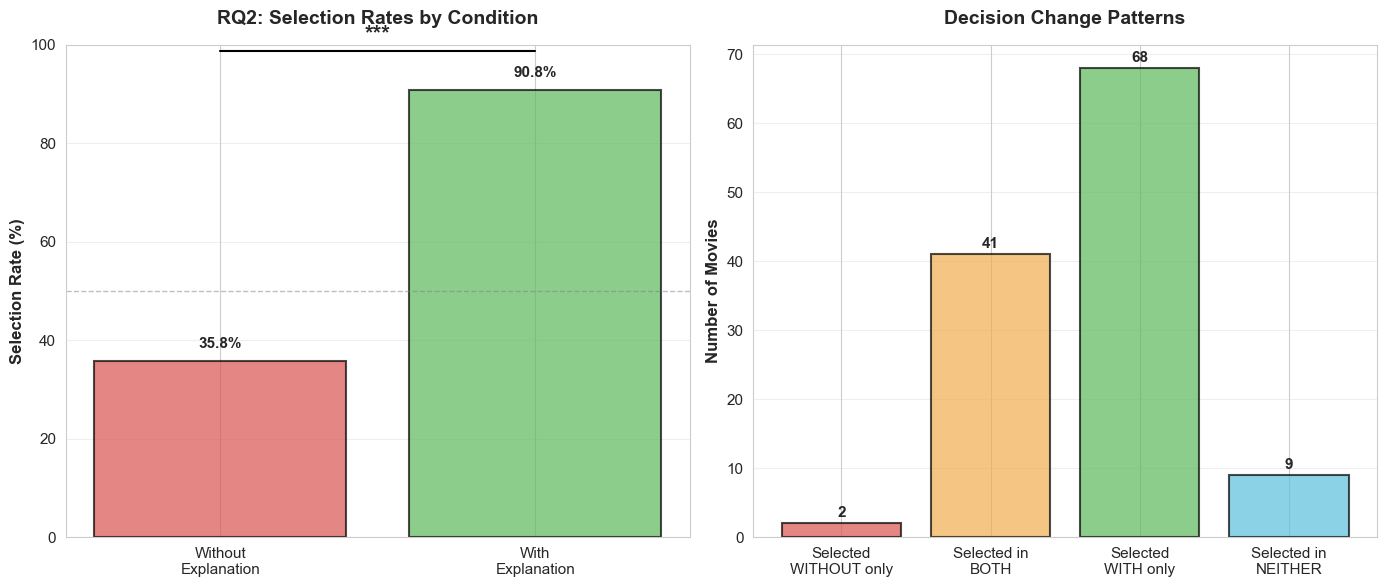

In [6]:
# Section 6: RQ2 Visualization
print("\nSECTION 6: RQ2 VISUALIZATION")
print("=" * 60)

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Bar chart comparing selection rates
ax1 = axes[0]
conditions = ['Without\nExplanation', 'With\nExplanation']
rates = [selection_no_exp * 100, selection_with_exp * 100]

bars = ax1.bar(conditions, rates, color=['#d9534f', '#5cb85c'], alpha=0.7, edgecolor='black', linewidth=1.5)

ax1.set_ylabel('Selection Rate (%)', fontsize=12, fontweight='bold')
ax1.set_title('RQ2: Selection Rates by Condition', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylim(0, 100)
ax1.axhline(y=50, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, rate) in enumerate(zip(bars, rates)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{rate:.1f}%',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add significance annotation
if mcnemar_p < 0.05:
    y_max = max(rates) + 8
    ax1.plot([0, 1], [y_max, y_max], 'k-', linewidth=1.5)
    sig_text = '***' if mcnemar_p < 0.001 else '**' if mcnemar_p < 0.01 else '*'
    ax1.text(0.5, y_max + 2, sig_text, ha='center', fontsize=16, fontweight='bold')

# Plot 2: Decision changes
ax2 = axes[1]

# Create categories for the flow
categories = ['Selected\nWITHOUT only', 'Selected in\nBOTH', 'Selected\nWITH only', 'Selected in\nNEITHER']
values = [yes_then_no, both_yes, no_then_yes, both_no]
colors_flow = ['#d9534f', '#f0ad4e', '#5cb85c', '#5bc0de']

bars2 = ax2.bar(categories, values, color=colors_flow, alpha=0.7, edgecolor='black', linewidth=1.5)

ax2.set_ylabel('Number of Movies', fontsize=12, fontweight='bold')
ax2.set_title('Decision Change Patterns', fontsize=14, fontweight='bold', pad=15)
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bar, value in zip(bars2, values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{int(value)}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Rotate x labels for readability
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('rq2_selection_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Chart saved as: rq2_selection_comparison.png")
plt.show()

print("\n" + "=" * 60)

In [7]:
# Section 7: RQ3 Analysis - Explanation Type Comparison
print("\nSECTION 7: RQ3 - DO EXPLANATION TYPES DIFFER IN EFFECTIVENESS?")
print("=" * 60)

# Filter only data WHERE explanations were shown
exp_data = df[df['explanation_shown'] == True].copy()

print("\nData for RQ3:")
print(f"  Total observations with explanations: {len(exp_data)}")

# Check distribution across types
type_counts = exp_data['explanation_type'].value_counts()
print(f"\n  Distribution by type:")
for exp_type, count in type_counts.items():
    print(f"    {exp_type.capitalize()}: {count} observations")

# =========================================================
# RQ3a: Trust by Explanation Type
# =========================================================

print("\n" + "-" * 60)
print("RQ3a: TRUST by Explanation Type")
print("-" * 60)

# Calculate mean trust for each type
trust_by_type = exp_data.groupby('explanation_type')['trust_mean'].agg(['mean', 'std', 'count'])
trust_by_type = trust_by_type.sort_values('mean', ascending=False)

print("\nDescriptive Statistics - Trust by Type:")
for exp_type in trust_by_type.index:
    mean_val = trust_by_type.loc[exp_type, 'mean']
    std_val = trust_by_type.loc[exp_type, 'std']
    count_val = int(trust_by_type.loc[exp_type, 'count'])
    print(f"  {exp_type.capitalize()}:")
    print(f"    Mean: {mean_val:.3f}")
    print(f"    SD: {std_val:.3f}")
    print(f"    N: {count_val}")

# Prepare data for repeated measures ANOVA
# We need trust scores for each participant in each explanation type
trust_rating = exp_data[exp_data['explanation_type'] == 'rating'].groupby('participant_id')['trust_mean'].mean()
trust_similarity = exp_data[exp_data['explanation_type'] == 'similarity'].groupby('participant_id')['trust_mean'].mean()
trust_popularity = exp_data[exp_data['explanation_type'] == 'popularity'].groupby('participant_id')['trust_mean'].mean()

# Friedman test (non-parametric alternative to repeated measures ANOVA)
# Use this because same participants see all three types
from scipy.stats import friedmanchisquare

# Align participants (ensure same order)
common_participants = trust_rating.index.intersection(trust_similarity.index).intersection(trust_popularity.index)
trust_rating_aligned = trust_rating.loc[common_participants].values
trust_similarity_aligned = trust_similarity.loc[common_participants].values
trust_popularity_aligned = trust_popularity.loc[common_participants].values

friedman_stat, friedman_p = friedmanchisquare(trust_rating_aligned, trust_similarity_aligned, trust_popularity_aligned)

print("\nStatistical Test - Friedman Test (Trust):")
print(f"  Chi-square statistic: {friedman_stat:.4f}")
print(f"  p-value: {friedman_p:.6f}")

# Interpret
if friedman_p < 0.001:
    sig_level_trust = "p < 0.001 (highly significant)"
elif friedman_p < 0.01:
    sig_level_trust = "p < 0.01 (very significant)"
elif friedman_p < 0.05:
    sig_level_trust = "p < 0.05 (significant)"
else:
    sig_level_trust = f"p = {friedman_p:.3f} (not significant)"

print(f"\nInterpretation:")
print(f"  Significance: {sig_level_trust}")

# Effect size (Kendall's W)
n = len(common_participants)
k = 3  # number of conditions
kendalls_w = friedman_stat / (n * (k - 1))
print(f"  Kendall's W (effect size): {kendalls_w:.3f}")

if kendalls_w < 0.3:
    effect_trust = "small"
elif kendalls_w < 0.5:
    effect_trust = "medium"
else:
    effect_trust = "large"

print(f"  Effect size interpretation: {effect_trust}")

print("\nConclusion (Trust):")
if friedman_p < 0.05:
    print(f"  ✓ RQ3a SUPPORTED: Explanation types differ significantly in trust")
    print(f"    Ranking: {trust_by_type.index[0].capitalize()} > {trust_by_type.index[1].capitalize()} > {trust_by_type.index[2].capitalize()}")
else:
    print(f"  ✗ RQ3a NOT SUPPORTED: No significant difference in trust across types")

# =========================================================
# RQ3b: Selection Behavior by Explanation Type
# =========================================================

print("\n" + "-" * 60)
print("RQ3b: SELECTION BEHAVIOR by Explanation Type")
print("-" * 60)

# Calculate selection rate for each type
selection_by_type = exp_data.groupby('explanation_type')['decision'].agg(['mean', 'sum', 'count'])
selection_by_type = selection_by_type.sort_values('mean', ascending=False)

print("\nDescriptive Statistics - Selection Rate by Type:")
for exp_type in selection_by_type.index:
    rate = selection_by_type.loc[exp_type, 'mean']
    selected = int(selection_by_type.loc[exp_type, 'sum'])
    total = int(selection_by_type.loc[exp_type, 'count'])
    print(f"  {exp_type.capitalize()}:")
    print(f"    Selection rate: {rate:.1%}")
    print(f"    Selected: {selected} / {total}")

# Chi-square test for independence
from scipy.stats import chi2_contingency

# Create contingency table
contingency_table = pd.crosstab(exp_data['explanation_type'], exp_data['decision'])
print("\nContingency Table:")
print(contingency_table)

chi2_stat, chi2_p, chi2_dof, chi2_expected = chi2_contingency(contingency_table)

print("\nStatistical Test - Chi-Square Test (Selection):")
print(f"  Chi-square statistic: {chi2_stat:.4f}")
print(f"  Degrees of freedom: {chi2_dof}")
print(f"  p-value: {chi2_p:.6f}")

# Interpret
if chi2_p < 0.001:
    sig_level_sel = "p < 0.001 (highly significant)"
elif chi2_p < 0.01:
    sig_level_sel = "p < 0.01 (very significant)"
elif chi2_p < 0.05:
    sig_level_sel = "p < 0.05 (significant)"
else:
    sig_level_sel = f"p = {chi2_p:.3f} (not significant)"

print(f"\nInterpretation:")
print(f"  Significance: {sig_level_sel}")

# Cramér's V (effect size for chi-square)
n_obs = len(exp_data)
cramers_v = np.sqrt(chi2_stat / (n_obs * (min(contingency_table.shape) - 1)))
print(f"  Cramér's V (effect size): {cramers_v:.3f}")

if cramers_v < 0.3:
    effect_sel = "small"
elif cramers_v < 0.5:
    effect_sel = "medium"
else:
    effect_sel = "large"

print(f"  Effect size interpretation: {effect_sel}")

print("\nConclusion (Selection):")
if chi2_p < 0.05:
    print(f"  ✓ RQ3b SUPPORTED: Explanation types differ significantly in selection behavior")
    print(f"    Ranking: {selection_by_type.index[0].capitalize()} > {selection_by_type.index[1].capitalize()} > {selection_by_type.index[2].capitalize()}")
else:
    print(f"  ✗ RQ3b NOT SUPPORTED: No significant difference in selection across types")

# =========================================================
# Overall RQ3 Summary
# =========================================================

print("\n" + "=" * 60)
print("RQ3 OVERALL SUMMARY")
print("=" * 60)

print("\nTrust Rankings:")
for i, exp_type in enumerate(trust_by_type.index, 1):
    mean_val = trust_by_type.loc[exp_type, 'mean']
    print(f"  {i}. {exp_type.capitalize()}: {mean_val:.3f}")

print("\nSelection Rate Rankings:")
for i, exp_type in enumerate(selection_by_type.index, 1):
    rate = selection_by_type.loc[exp_type, 'mean']
    print(f"  {i}. {exp_type.capitalize()}: {rate:.1%}")

print("\n" + "=" * 60)


SECTION 7: RQ3 - DO EXPLANATION TYPES DIFFER IN EFFECTIVENESS?

Data for RQ3:
  Total observations with explanations: 120

  Distribution by type:
    Similarity: 40 observations
    Rating: 40 observations
    Popularity: 40 observations

------------------------------------------------------------
RQ3a: TRUST by Explanation Type
------------------------------------------------------------

Descriptive Statistics - Trust by Type:
  Similarity:
    Mean: 4.405
    SD: 0.459
    N: 40
  Popularity:
    Mean: 4.285
    SD: 0.621
    N: 40
  Rating:
    Mean: 4.125
    SD: 0.674
    N: 40

Statistical Test - Friedman Test (Trust):
  Chi-square statistic: 2.9067
  p-value: 0.233790

Interpretation:
  Significance: p = 0.234 (not significant)
  Kendall's W (effect size): 0.073
  Effect size interpretation: small

Conclusion (Trust):
  ✗ RQ3a NOT SUPPORTED: No significant difference in trust across types

------------------------------------------------------------
RQ3b: SELECTION BEHAVIOR 


SECTION 8: RQ3 VISUALIZATION

✓ Chart saved as: rq3_explanation_type_comparison.png


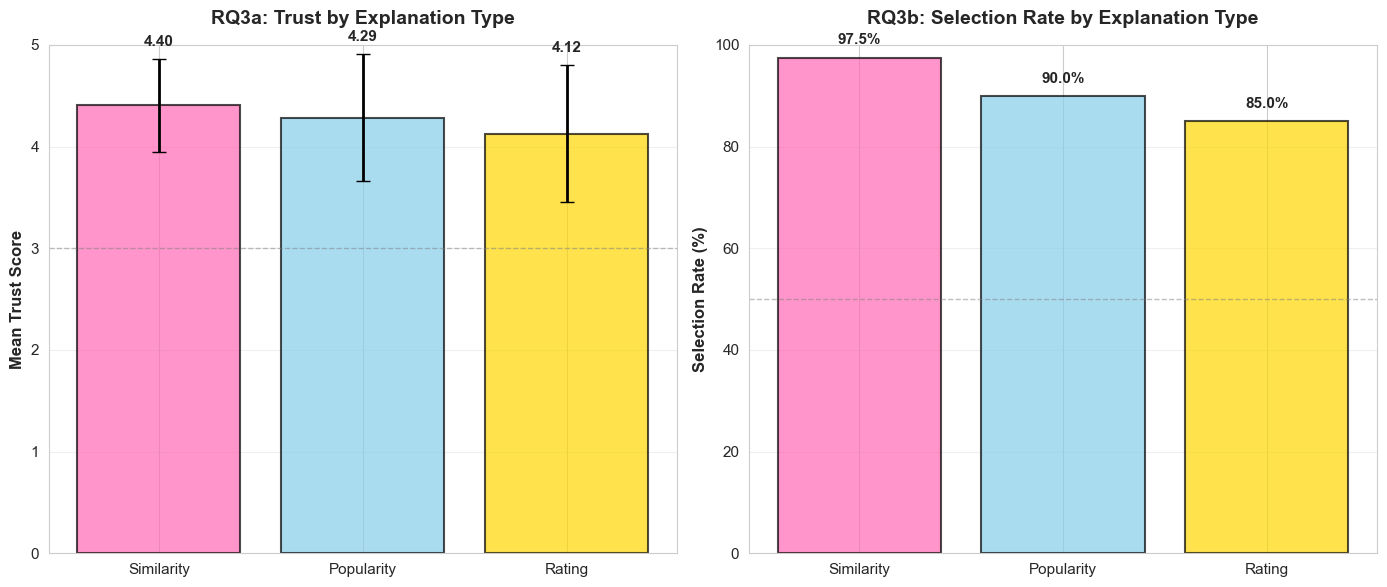

In [8]:
# Section 8: RQ3 Visualization
print("\nSECTION 8: RQ3 VISUALIZATION")
print("=" * 60)

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# =========================================================
# Plot 1: Trust by Explanation Type
# =========================================================

ax1 = axes[0]

# Prepare data
types = trust_by_type.index.tolist()
means = trust_by_type['mean'].values
stds = trust_by_type['std'].values

# Map colors
colors_map = {
    'rating': '#FFD700',      # Gold
    'similarity': '#FF69B4',  # Pink
    'popularity': '#87CEEB'   # Sky blue
}
bar_colors = [colors_map.get(t, '#999999') for t in types]

# Create bar chart
bars1 = ax1.bar([t.capitalize() for t in types], means, 
                color=bar_colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.errorbar([t.capitalize() for t in types], means, yerr=stds, 
             fmt='none', color='black', capsize=5, linewidth=2)

ax1.set_ylabel('Mean Trust Score', fontsize=12, fontweight='bold')
ax1.set_title('RQ3a: Trust by Explanation Type', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylim(0, 5)
ax1.axhline(y=3, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for i, (bar, mean, std) in enumerate(zip(bars1, means, stds)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + std + 0.1,
             f'{mean:.2f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add significance annotation if significant
if friedman_p < 0.05:
    ax1.text(0.5, 4.7, f'Friedman χ² = {friedman_stat:.2f}, {sig_level_trust}',
             ha='center', fontsize=9, style='italic',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

# =========================================================
# Plot 2: Selection Rate by Explanation Type
# =========================================================

ax2 = axes[1]

# Prepare data
types_sel = selection_by_type.index.tolist()
rates = selection_by_type['mean'].values * 100  # Convert to percentage

bar_colors_sel = [colors_map.get(t, '#999999') for t in types_sel]

# Create bar chart
bars2 = ax2.bar([t.capitalize() for t in types_sel], rates,
                color=bar_colors_sel, alpha=0.7, edgecolor='black', linewidth=1.5)

ax2.set_ylabel('Selection Rate (%)', fontsize=12, fontweight='bold')
ax2.set_title('RQ3b: Selection Rate by Explanation Type', fontsize=14, fontweight='bold', pad=15)
ax2.set_ylim(0, 100)
ax2.axhline(y=50, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bar, rate in zip(bars2, rates):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{rate:.1f}%',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add significance annotation if significant
if chi2_p < 0.05:
    ax2.text(0.5, 92, f'χ² = {chi2_stat:.2f}, {sig_level_sel}',
             ha='center', fontsize=9, style='italic',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.savefig('rq3_explanation_type_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Chart saved as: rq3_explanation_type_comparison.png")
plt.show()

print("\n" + "=" * 60)

In [9]:
# Section 9: Summary Tables for Paper
print("\nSECTION 9: SUMMARY TABLES FOR PAPER")
print("=" * 60)

# =========================================================
# Table 1: Participant Demographics
# =========================================================

print("\nTable 1: Participant Demographics")
print("-" * 60)

# Get unique participants
participant_data = df.groupby('participant_id').first()

print(f"Total Participants: N = {len(participant_data)}")
print(f"\nAge: Not collected")
print(f"Gender: Not collected")

print(f"\nCondition Order:")
order_counts = participant_data['condition_order'].value_counts()
for order, count in order_counts.items():
    pct = (count / len(participant_data)) * 100
    print(f"  {order}: {count} ({pct:.1f}%)")

print(f"\nTop 5 Favorite Genres:")
genre_counts = participant_data['favorite_genre'].value_counts().head(5)
for genre, count in genre_counts.items():
    pct = (count / len(participant_data)) * 100
    print(f"  {genre}: {count} ({pct:.1f}%)")

print(f"\nTop 5 Preferred Moods:")
mood_counts = participant_data['mood'].value_counts().head(5)
for mood, count in mood_counts.items():
    pct = (count / len(participant_data)) * 100
    print(f"  {mood}: {count} ({pct:.1f}%)")

# =========================================================
# Table 2: Descriptive Statistics by Condition
# =========================================================

print("\n" + "=" * 60)
print("\nTable 2: Descriptive Statistics by Condition")
print("-" * 60)

# Trust scores
trust_stats = df.groupby('explanation_shown')['trust_mean'].agg(['mean', 'std', 'min', 'max', 'count'])
trust_stats.index = ['Without Explanation', 'With Explanation']

print("\nTrust Scores:")
print(f"{'Condition':<25} {'Mean':<10} {'SD':<10} {'Min':<10} {'Max':<10} {'N':<10}")
print("-" * 75)
for idx, row in trust_stats.iterrows():
    print(f"{idx:<25} {row['mean']:<10.3f} {row['std']:<10.3f} {row['min']:<10.3f} {row['max']:<10.3f} {int(row['count']):<10}")

# Selection rates
selection_stats = df.groupby('explanation_shown')['decision'].agg(['mean', 'sum', 'count'])
selection_stats.index = ['Without Explanation', 'With Explanation']

print("\nSelection Behavior:")
print(f"{'Condition':<25} {'Rate':<15} {'Selected':<15} {'Total':<10}")
print("-" * 65)
for idx, row in selection_stats.iterrows():
    print(f"{idx:<25} {row['mean']:<15.1%} {int(row['sum']):<15} {int(row['count']):<10}")

# =========================================================
# Table 3: Statistical Test Results Summary
# =========================================================

print("\n" + "=" * 60)
print("\nTable 3: Statistical Test Results Summary")
print("-" * 60)

# Create results table
results_data = []

# RQ1
results_data.append({
    'Research Question': 'RQ1: Do explanations increase trust?',
    'Test': 'Paired t-test',
    'Statistic': f't({len(trust_without)-1}) = {t_stat:.3f}',
    'p-value': f'{p_value:.6f}',
    'Effect Size': f"Cohen's d = {cohens_d:.3f}",
    'Result': '✓ Supported' if p_value < 0.05 else '✗ Not Supported'
})

# RQ2
results_data.append({
    'Research Question': 'RQ2: Do explanations increase selection?',
    'Test': "McNemar's test",
    'Statistic': f'χ²(1) = {mcnemar_stat:.3f}',
    'p-value': f'{mcnemar_p:.6f}',
    'Effect Size': f'OR = {(c/b if b > 0 else "∞"):.2f}' if c > 0 else 'N/A',
    'Result': '✓ Supported' if mcnemar_p < 0.05 else '✗ Not Supported'
})

# RQ3a
results_data.append({
    'Research Question': 'RQ3a: Do types differ in trust?',
    'Test': 'Friedman test',
    'Statistic': f'χ²(2) = {friedman_stat:.3f}',
    'p-value': f'{friedman_p:.6f}',
    'Effect Size': f"Kendall's W = {kendalls_w:.3f}",
    'Result': '✓ Supported' if friedman_p < 0.05 else '✗ Not Supported'
})

# RQ3b
results_data.append({
    'Research Question': 'RQ3b: Do types differ in selection?',
    'Test': 'Chi-square test',
    'Statistic': f'χ²({chi2_dof}) = {chi2_stat:.3f}',
    'p-value': f'{chi2_p:.6f}',
    'Effect Size': f"Cramér's V = {cramers_v:.3f}",
    'Result': '✓ Supported' if chi2_p < 0.05 else '✗ Not Supported'
})

results_df = pd.DataFrame(results_data)

print("\n")
for col in results_df.columns:
    print(f"{col:<40}", end="")
print()
print("-" * 200)

for _, row in results_df.iterrows():
    for col in results_df.columns:
        print(f"{row[col]:<40}", end="")
    print()

# =========================================================
# Table 4: Explanation Type Performance
# =========================================================

print("\n" + "=" * 60)
print("\nTable 4: Explanation Type Performance")
print("-" * 60)

# Combine trust and selection by type
type_summary = pd.DataFrame({
    'Trust Mean': trust_by_type['mean'],
    'Trust SD': trust_by_type['std'],
    'Selection Rate': selection_by_type['mean'],
    'N': trust_by_type['count']
})

type_summary = type_summary.sort_values('Trust Mean', ascending=False)

print(f"\n{'Type':<15} {'Trust Mean':<15} {'Trust SD':<15} {'Selection Rate':<20} {'N':<10}")
print("-" * 75)
for idx, row in type_summary.iterrows():
    print(f"{idx.capitalize():<15} {row['Trust Mean']:<15.3f} {row['Trust SD']:<15.3f} {row['Selection Rate']:<20.1%} {int(row['N']):<10}")

# =========================================================
# Export Tables to CSV for easy import into Word
# =========================================================

print("\n" + "=" * 60)
print("\nExporting tables to CSV files...")

# Export demographics
demo_export = pd.DataFrame({
    'Metric': ['Total Participants', 'Condition Order', 'Top Genre', 'Top Mood'],
    'Value': [
        len(participant_data),
        f"{order_counts.index[0]}: {order_counts.iloc[0]}",
        f"{genre_counts.index[0]}: {genre_counts.iloc[0]}",
        f"{mood_counts.index[0]}: {mood_counts.iloc[0]}"
    ]
})
demo_export.to_csv('table1_demographics.csv', index=False)
print("  ✓ table1_demographics.csv")

# Export descriptive stats
trust_stats_export = trust_stats.reset_index()
trust_stats_export.columns = ['Condition', 'Mean', 'SD', 'Min', 'Max', 'N']
trust_stats_export.to_csv('table2_descriptive_stats.csv', index=False)
print("  ✓ table2_descriptive_stats.csv")

# Export statistical results
results_df.to_csv('table3_statistical_results.csv', index=False)
print("  ✓ table3_statistical_results.csv")

# Export explanation type performance
type_summary_export = type_summary.reset_index()
type_summary_export.columns = ['Type', 'Trust Mean', 'Trust SD', 'Selection Rate', 'N']
type_summary_export.to_csv('table4_explanation_types.csv', index=False)
print("  ✓ table4_explanation_types.csv")

print("\n" + "=" * 60)
print("ANALYSIS COMPLETE!")
print("=" * 60)
print("\nGenerated Files:")
print("  📊 rq1_trust_comparison.png")
print("  📊 rq2_selection_comparison.png")
print("  📊 rq3_explanation_type_comparison.png")
print("  📄 table1_demographics.csv")
print("  📄 table2_descriptive_stats.csv")
print("  📄 table3_statistical_results.csv")
print("  📄 table4_explanation_types.csv")
print("\nAll tables ready to copy into your paper!")
print("=" * 60)


SECTION 9: SUMMARY TABLES FOR PAPER

Table 1: Participant Demographics
------------------------------------------------------------
Total Participants: N = 20

Age: Not collected
Gender: Not collected

Condition Order:
  No_Explanation_First: 20 (100.0%)

Top 5 Favorite Genres:
  Horror: 4 (20.0%)
  Children: 3 (15.0%)
  Thriller: 3 (15.0%)
  Comedy: 2 (10.0%)
  Sci-Fi: 2 (10.0%)

Top 5 Preferred Moods:
  fun: 6 (30.0%)
  thrilling: 4 (20.0%)
  dark: 3 (15.0%)
  mind-bending: 3 (15.0%)
  emotional: 2 (10.0%)


Table 2: Descriptive Statistics by Condition
------------------------------------------------------------

Trust Scores:
Condition                 Mean       SD         Min        Max        N         
---------------------------------------------------------------------------
Without Explanation       2.318      0.854      1.000      4.000      120       
With Explanation          4.272      0.598      2.200      5.000      120       

Selection Behavior:
Condition             

In [10]:
# Section 10: Decision Time Analysis (Additional Finding)
print("\nSECTION 10: DECISION TIME ANALYSIS")
print("=" * 60)

# Calculate decision times
time_no_exp = no_exp_data['decision_time'].mean()
time_with_exp = with_exp_data['decision_time'].mean()
time_diff = time_with_exp - time_no_exp

print("\nDescriptive Statistics - Decision Time:")
print(f"  Without Explanation:")
print(f"    Mean: {time_no_exp:.2f} seconds")
print(f"    SD: {no_exp_data['decision_time'].std():.2f} seconds")
print(f"    Min: {no_exp_data['decision_time'].min():.2f} seconds")
print(f"    Max: {no_exp_data['decision_time'].max():.2f} seconds")

print(f"\n  With Explanation:")
print(f"    Mean: {time_with_exp:.2f} seconds")
print(f"    SD: {with_exp_data['decision_time'].std():.2f} seconds")
print(f"    Min: {with_exp_data['decision_time'].min():.2f} seconds")
print(f"    Max: {with_exp_data['decision_time'].max():.2f} seconds")

print(f"\n  Difference: {time_diff:+.2f} seconds")
print(f"  Percentage change: {(time_diff/time_no_exp)*100:+.1f}%")

# Prepare paired data
time_paired = df.groupby(['participant_id', 'explanation_shown'])['decision_time'].mean().unstack()
time_without = time_paired[False].values
time_with = time_paired[True].values

# Paired t-test for decision time
t_time, p_time = ttest_rel(time_with, time_without)

# Cohen's d for paired samples
diff_time = time_with - time_without
cohens_d_time = diff_time.mean() / diff_time.std()

print("\nStatistical Test - Paired t-test:")
print(f"  t-statistic: {t_time:.4f}")
print(f"  p-value: {p_time:.6f}")
print(f"  Cohen's d: {cohens_d_time:.4f}")

# Interpret significance
if p_time < 0.001:
    sig_level_time = "p < 0.001 (highly significant)"
elif p_time < 0.01:
    sig_level_time = "p < 0.01 (very significant)"
elif p_time < 0.05:
    sig_level_time = "p < 0.05 (significant)"
else:
    sig_level_time = f"p = {p_time:.3f} (not significant)"

print(f"\nInterpretation:")
print(f"  Significance: {sig_level_time}")

# Interpret effect size
if abs(cohens_d_time) < 0.2:
    effect_time = "negligible"
elif abs(cohens_d_time) < 0.5:
    effect_time = "small"
elif abs(cohens_d_time) < 0.8:
    effect_time = "medium"
else:
    effect_time = "large"

print(f"  Effect size: {effect_time}")

print("\nConclusion:")
if p_time < 0.05:
    direction = "increased" if time_diff > 0 else "reduced"
    print(f"  ✓ Explanations significantly {direction} decision time")
    print(f"    (Mean difference = {time_diff:+.2f}s, {sig_level_time}, d = {cohens_d_time:.3f})")
    
    # Practical interpretation
    if time_diff > 0:
        print(f"\n  💡 Practical Interpretation:")
        print(f"     Users took {abs(time_diff):.1f}s longer to decide WITH explanations.")
        print(f"     This suggests explanations require additional cognitive processing.")
        print(f"     However, the benefit in trust (+{trust_with_exp - trust_no_exp:.2f} points)")
        print(f"     and selection rate (+{(selection_with_exp - selection_no_exp)*100:.1f}%)")
        print(f"     may justify this small time cost.")
    else:
        print(f"\n  💡 Practical Interpretation:")
        print(f"     Users decided {abs(time_diff):.1f}s FASTER with explanations.")
        print(f"     This suggests explanations REDUCE cognitive load and decision uncertainty.")
        print(f"     Users feel more confident and can decide more quickly.")
else:
    print(f"  ✓ No significant difference in decision time")
    print(f"\n  💡 Practical Interpretation:")
    print(f"     Explanations increased trust (+{trust_with_exp - trust_no_exp:.2f} points)")
    print(f"     and selection rate (+{(selection_with_exp - selection_no_exp)*100:.1f}%)")
    print(f"     WITHOUT slowing users down - efficiency preserved!")
    print(f"     This is ideal: better decisions at no time cost.")

# Decision time by explanation type (exploratory)
print("\n" + "-" * 60)
print("Exploratory: Decision Time by Explanation Type")
print("-" * 60)

time_by_type = exp_data.groupby('explanation_type')['decision_time'].agg(['mean', 'std', 'count'])
time_by_type = time_by_type.sort_values('mean', ascending=True)

print(f"\n{'Type':<15} {'Mean (s)':<12} {'SD (s)':<12} {'N':<10}")
print("-" * 50)
for exp_type in time_by_type.index:
    mean_val = time_by_type.loc[exp_type, 'mean']
    std_val = time_by_type.loc[exp_type, 'std']
    count_val = int(time_by_type.loc[exp_type, 'count'])
    print(f"{exp_type.capitalize():<15} {mean_val:<12.2f} {std_val:<12.2f} {count_val:<10}")

print("\n" + "=" * 60)


SECTION 10: DECISION TIME ANALYSIS

Descriptive Statistics - Decision Time:
  Without Explanation:
    Mean: 6.72 seconds
    SD: 5.15 seconds
    Min: 1.55 seconds
    Max: 46.08 seconds

  With Explanation:
    Mean: 7.05 seconds
    SD: 11.03 seconds
    Min: 1.23 seconds
    Max: 109.84 seconds

  Difference: +0.32 seconds
  Percentage change: +4.8%

Statistical Test - Paired t-test:
  t-statistic: 0.2976
  p-value: 0.769264
  Cohen's d: 0.0683

Interpretation:
  Significance: p = 0.769 (not significant)
  Effect size: negligible

Conclusion:
  ✓ No significant difference in decision time

  💡 Practical Interpretation:
     Explanations increased trust (+1.95 points)
     and selection rate (+55.0%)
     WITHOUT slowing users down - efficiency preserved!
     This is ideal: better decisions at no time cost.

------------------------------------------------------------
Exploratory: Decision Time by Explanation Type
------------------------------------------------------------

Type 


SECTION 11: DECISION TIME VISUALIZATION

✓ Chart saved as: decision_time_analysis.png


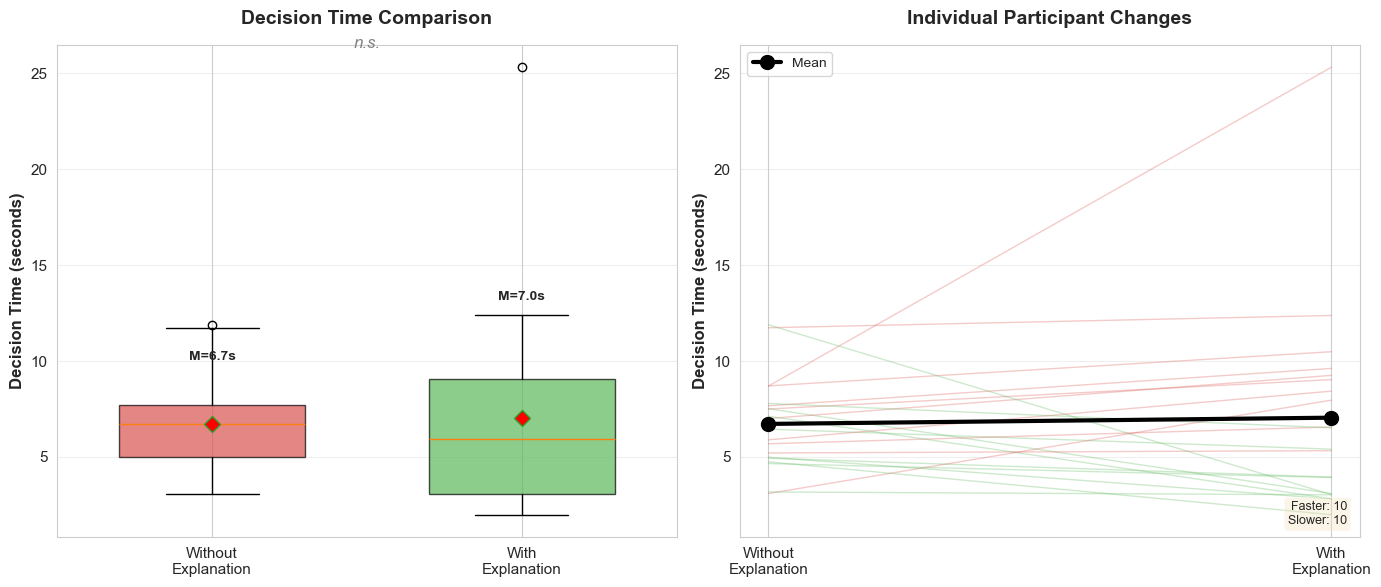

In [11]:
# Section 11: Decision Time Visualization
print("\nSECTION 11: DECISION TIME VISUALIZATION")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# =========================================================
# Plot 1: Box plot comparison
# =========================================================
ax1 = axes[0]
positions = [1, 2]
data_to_plot = [time_without, time_with]

bp = ax1.boxplot(data_to_plot, positions=positions, widths=0.6, patch_artist=True,
                showmeans=True, meanprops=dict(marker='D', markerfacecolor='red', markersize=8))

for patch, color in zip(bp['boxes'], ['#d9534f', '#5cb85c']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax1.set_xticks(positions)
ax1.set_xticklabels(['Without\nExplanation', 'With\nExplanation'])
ax1.set_ylabel('Decision Time (seconds)', fontsize=12, fontweight='bold')
ax1.set_title('Decision Time Comparison', fontsize=14, fontweight='bold', pad=15)
ax1.grid(axis='y', alpha=0.3)

# Add mean values as text
ax1.text(1, time_without.mean() + time_without.std() + 1, 
         f'M={time_without.mean():.1f}s', 
         ha='center', fontsize=10, fontweight='bold')
ax1.text(2, time_with.mean() + time_with.std() + 1, 
         f'M={time_with.mean():.1f}s', 
         ha='center', fontsize=10, fontweight='bold')

# Add significance annotation if applicable
if p_time < 0.05:
    y_max = max(time_with.max(), time_without.max())
    ax1.plot([1, 2], [y_max + 1, y_max + 1], 'k-', linewidth=1.5)
    sig_text = '***' if p_time < 0.001 else '**' if p_time < 0.01 else '*'
    ax1.text(1.5, y_max + 1.5, sig_text, ha='center', fontsize=16, fontweight='bold')
elif p_time >= 0.05:
    # Show "ns" for not significant
    y_max = max(time_with.max(), time_without.max())
    ax1.text(1.5, y_max + 1, 'n.s.', ha='center', fontsize=12, style='italic', color='gray')

# =========================================================
# Plot 2: Individual participant changes
# =========================================================
ax2 = axes[1]

# Plot each participant's change
faster_count = 0
slower_count = 0
same_count = 0

for i in range(len(time_without)):
    if time_with[i] < time_without[i]:
        color = '#5cb85c'  # Green if FASTER with explanation
        faster_count += 1
    elif time_with[i] > time_without[i]:
        color = '#d9534f'  # Red if SLOWER with explanation
        slower_count += 1
    else:
        color = '#999999'  # Gray if same
        same_count += 1
    
    alpha = 0.3
    ax2.plot([0, 1], [time_without[i], time_with[i]], 
             color=color, alpha=alpha, linewidth=1)

# Mean line (thick black)
ax2.plot([0, 1], [time_without.mean(), time_with.mean()], 
         color='black', linewidth=3, marker='o', markersize=10, label='Mean', zorder=10)

ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Without\nExplanation', 'With\nExplanation'], fontsize=11)
ax2.set_ylabel('Decision Time (seconds)', fontsize=12, fontweight='bold')
ax2.set_title('Individual Participant Changes', fontsize=14, fontweight='bold', pad=15)
ax2.grid(axis='y', alpha=0.3)
ax2.legend(fontsize=10)

# Add counts in legend box
legend_text = f"Faster: {faster_count}\nSlower: {slower_count}"
if same_count > 0:
    legend_text += f"\nSame: {same_count}"

ax2.text(0.98, 0.02, legend_text, transform=ax2.transAxes,
         fontsize=9, verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.savefig('decision_time_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Chart saved as: decision_time_analysis.png")
plt.show()

print("\n" + "=" * 60)

# Streamlit Dashboard